In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Advertising.csv')

# EDA

In [3]:
df.head(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [5]:
df.describe

<bound method NDFrame.describe of      Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]>

In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

# Data cleaning

In [16]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# OUTLIERS

<Axes: >

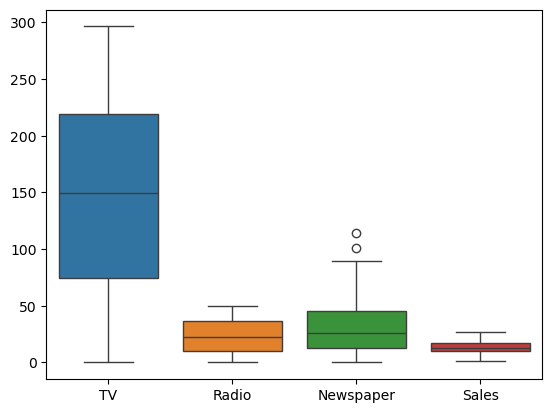

In [19]:
import seaborn as sns
sns.boxplot(data=df)

# Splitting Data

### we are taking multiple independent variables (tv,radio,newspaper) so this is multiple linear regression

In [21]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Sales'])
y=df['Sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Setting random_state=42 (or any fixed number) ensures that the split remains the same every time you run the script.If you don't set a random_state, the split will be different each time you run the code.

# Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [25]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [26]:
y_pred=lr.predict(X_test)

# Model Evaluation

In [28]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"Mean Scored Error:{mse}")
print(f"R2 Score:{r2}")

Mean Scored Error:3.174097353976104
R2 Score:0.899438024100912


# Visualization

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

## Pairplot

### pairplot visualizes relationships between all numerical variables in your dataset. It plots scatter plots between every pair of variables to observe relationships.It plots histograms along the diagonal to show the distribution of each variable.

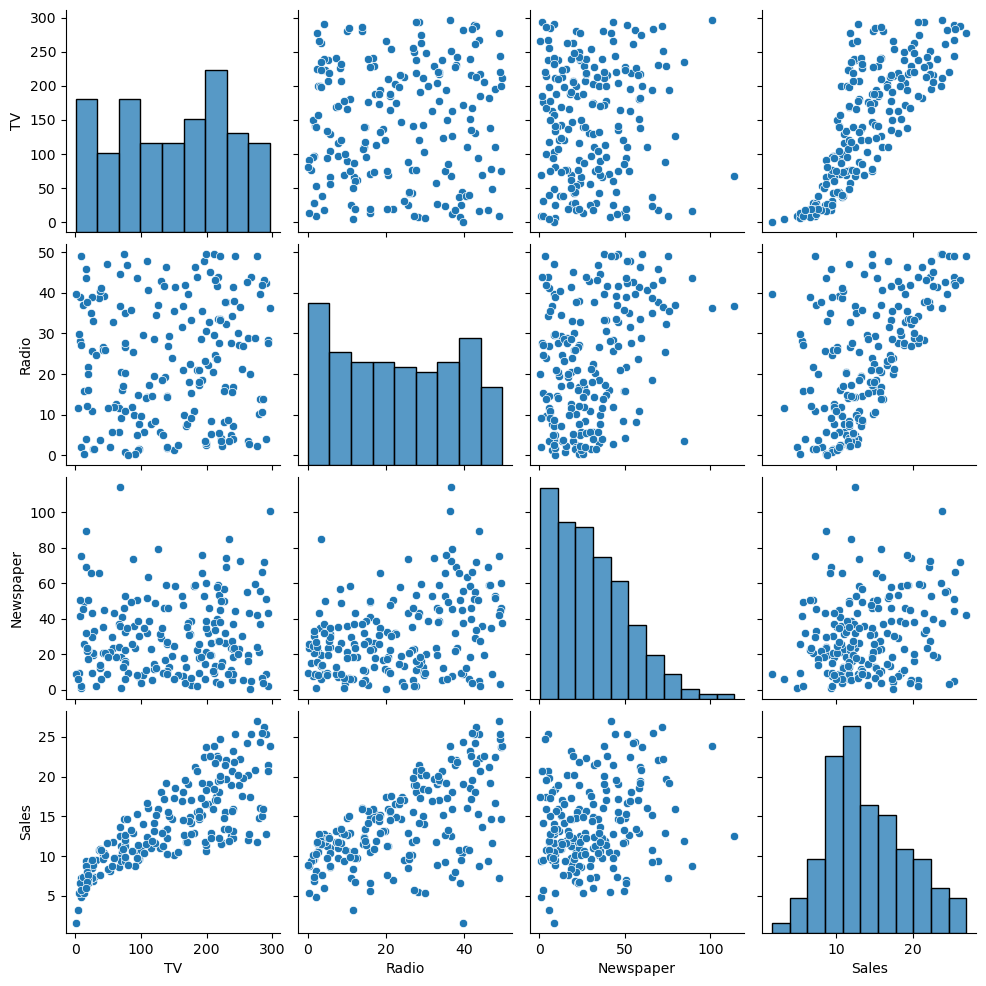

In [33]:
sns.pairplot(df)
plt.show()

### Pairplot observation
### 1.Tv vs Sales
### Shows a strong positive correlation (as TV budget increases, Sales increase).
### 2.Radio vs. Sales
### Shows some positive correlation but is weaker than TV.
### More scattered
### 3.Newspaper vs. Sales
### Appears randomly scattered → suggests little to no correlation with Sales.
### 4.Histograms on the diagonal
### TV and Radio have uniform-like distributions, meaning ad budgets are spread across different amounts.
### Newspaper has a right-skewed distribution, meaning fewer high-budget ad spends.
### Sales has a normal-like distribution, which is ideal for regression models.

## HeatMap

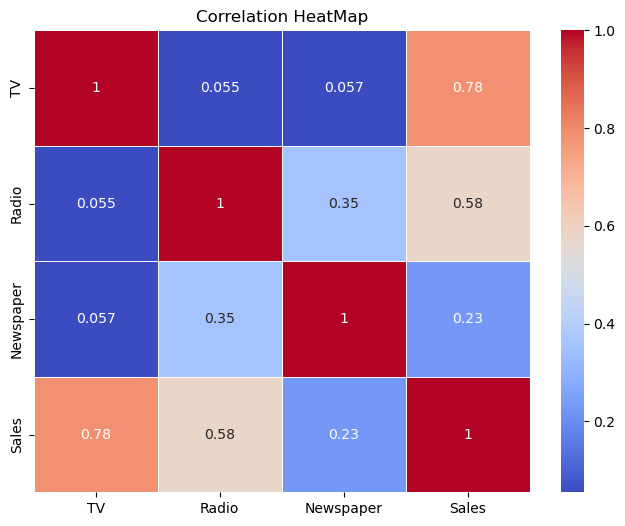

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",linewidth=0.5)
plt.title("Correlation HeatMap")
plt.show()

## correlation heatmap shows how strongly different features in your dataset are related to each other.
### Correlation values range from -1 to 1:
### 1 → Perfect positive correlation (both variables increase together)
### -1 → Perfect negative correlation (one increases while the other decreases)
### 0 → No correlation (variables are independent)

### TV & Sales: 0.78 (Strong Positive Correlation)

### Higher TV advertising spending is strongly linked to higher sales.

### TV seems to be the most influential factor for increasing sales.

### Radio & Sales: 0.58 (Moderate Positive Correlation)

### Radio ads also help boost sales, but not as much as TV.

### A moderate correlation suggests that increasing radio ads can still help sales.

### Newspaper & Sales: 0.23 (Weak Positive Correlation)

### Newspaper ads have the least impact on sales.

### A correlation of 0.23 suggests that investing more in newspapers may not significantly increase sales.

# Scatter Plot

## TV vs Sales

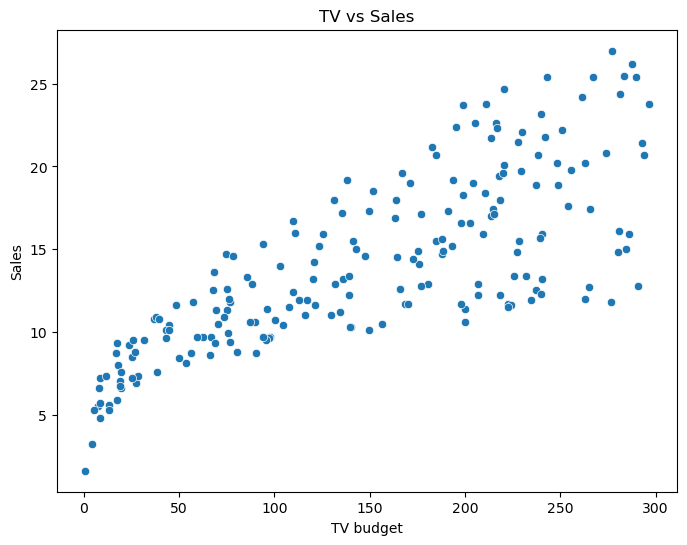

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['TV'],y=df['Sales'])
plt.xlabel("TV budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

# Radio vs Sales

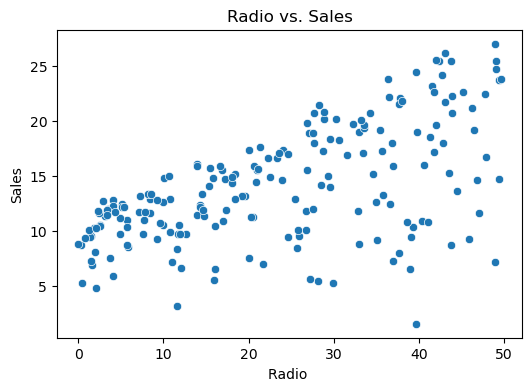

In [50]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Radio'], y=df['Sales'])
plt.xlabel("Radio ")
plt.ylabel("Sales")
plt.title("Radio vs. Sales")
plt.show()


# Newspaper vs. Sales

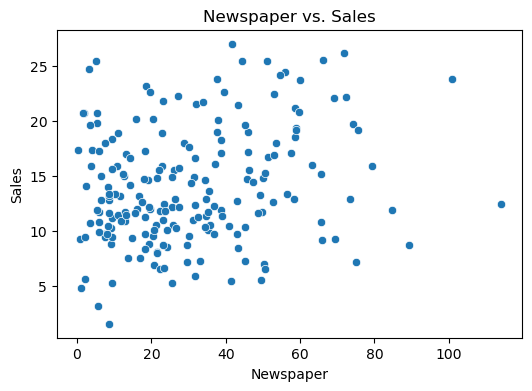

In [52]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Newspaper'], y=df['Sales'])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs. Sales")
plt.show()


# Regression Line

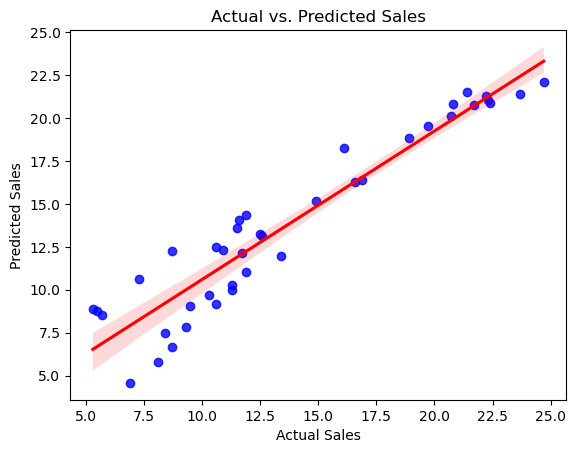

In [54]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color": "blue"}, line_kws={"color": "red"})
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.show()

### Good Fit: The blue dots (actual vs. predicted values) are closely aligned with the red regression line, suggesting that the model has a strong predictive ability.
### Positive Correlation: The red line slopes upwards, indicating a positive relationship—higher actual sales correspond to higher predicted sales.
### Some Scatter: A few points deviate from the line, meaning the model is making small errors in predicting sales.